# Cloud Count Oscillation Diagnostics

This notebook investigates why cloud counts oscillate between timesteps.
We test five main theories:

1. **Threshold Flickering** — Clouds near the liquid water threshold appear/disappear as ql fluctuates.
2. **Merge/Split Churning** — Merges absorb clouds, splits create new track IDs, inflating turnover.
3. **Identity Loss** — The tracker fails to match a continuing cloud, killing and re-creating it.
4. **Small-Cloud Turnover** — Most of the churn comes from small, short-lived clouds.
5. **Volume Conservation** — Does total cloud volume oscillate, or only cloud count?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from matplotlib.patches import FancyArrowPatch

nc_path = '../cloud_results.nc'

# ── Load all variables needed ──────────────────────────────────────────────
with Dataset(nc_path, 'r') as ds:
    size       = np.asarray(np.ma.filled(ds.variables['size'][:], np.nan), dtype=float)
    valid_mask = (np.asarray(ds.variables['valid_track'][:]) == 1)
    age        = np.asarray(np.ma.filled(ds.variables['age'][:], -1), dtype=int)
    split_from = np.asarray(np.ma.filled(ds.variables['split_from'][:], -1), dtype=int)
    merges_cnt = np.asarray(np.ma.filled(ds.variables['merges_count'][:], 0), dtype=int)
    splits_cnt = np.asarray(np.ma.filled(ds.variables['splits_count'][:], 0), dtype=int)
    loc_x      = np.asarray(np.ma.filled(ds.variables['location_x'][:], np.nan), dtype=float)
    loc_y      = np.asarray(np.ma.filled(ds.variables['location_y'][:], np.nan), dtype=float)
    loc_z      = np.asarray(np.ma.filled(ds.variables['location_z'][:], np.nan), dtype=float)
    surf_area  = np.asarray(np.ma.filled(ds.variables['surface_area'][:], np.nan), dtype=float)
    max_height = np.asarray(np.ma.filled(ds.variables['max_height'][:], np.nan), dtype=float)

    # Read config attributes
    h_res = float(ds.getncattr('horizontal_resolution'))
    dt    = float(ds.getncattr('timestep_duration'))
    l_cond = float(ds.getncattr('l_condition'))

    # Attempt to read domain size from coordinate arrays or config
    try:
        domain_x = float(ds.getncattr('domain_size_x'))
        domain_y = float(ds.getncattr('domain_size_y'))
    except AttributeError:
        # RICO default 256*25 = 6400m
        domain_x = 6400.0
        domain_y = 6400.0

n_tracks, n_time = size.shape
alive = np.isfinite(size)
t_axis = np.arange(n_time)

print(f'Loaded {n_tracks} tracks × {n_time} timesteps')
print(f'Config: l_condition={l_cond}, h_res={h_res}m, dt={dt}s')
print(f'Domain: {domain_x:.0f} × {domain_y:.0f} m')

Loaded 100000 tracks × 10 timesteps
Config: l_condition=0.0005, h_res=25.0m, dt=60.0s
Domain: 6400 × 6400 m


## 0. Overview: Cloud counts and volume over time

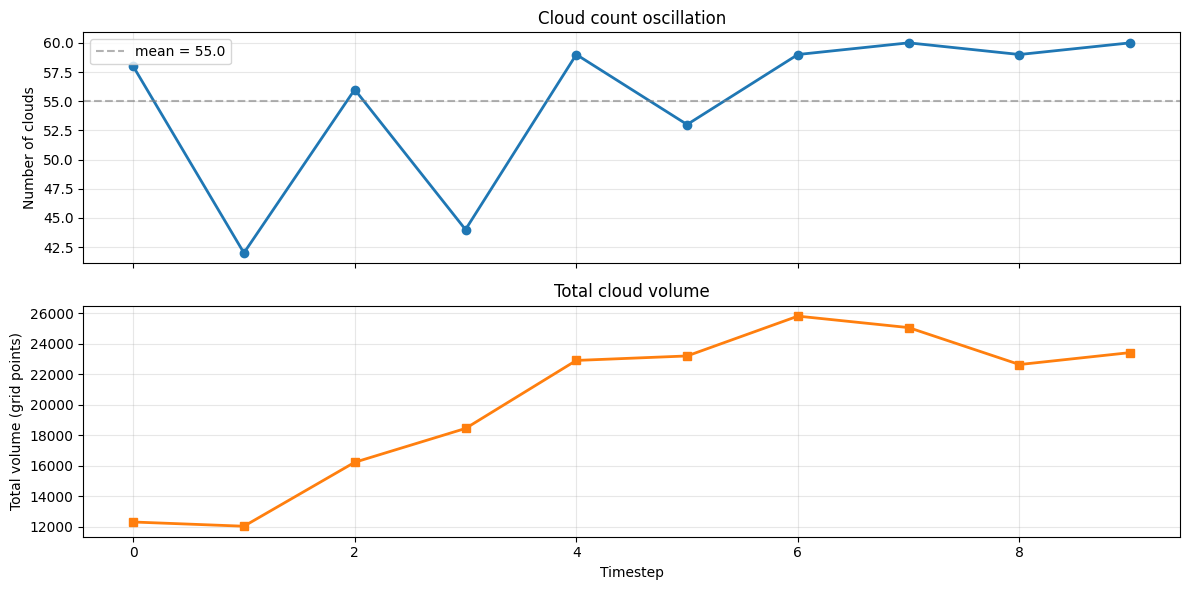

Cloud count range: 42 – 60 (amplitude 18, 33% of mean)


In [2]:
alive_count = alive.sum(axis=0)
volume_total = np.nansum(size, axis=0)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t_axis, alive_count, 'o-', lw=2, color='tab:blue')
axes[0].set_ylabel('Number of clouds')
axes[0].set_title('Cloud count oscillation')
axes[0].grid(True, alpha=0.3)
# Annotate range
axes[0].axhline(np.mean(alive_count), ls='--', color='grey', alpha=0.6, label=f'mean = {np.mean(alive_count):.1f}')
axes[0].legend()

axes[1].plot(t_axis, volume_total, 's-', lw=2, color='tab:orange')
axes[1].set_ylabel('Total volume (grid points)')
axes[1].set_xlabel('Timestep')
axes[1].set_title('Total cloud volume')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Cloud count range: {alive_count.min()} – {alive_count.max()} '
      f'(amplitude {alive_count.max()-alive_count.min()}, '
      f'{(alive_count.max()-alive_count.min())/np.mean(alive_count)*100:.0f}% of mean)')

## 1. Birth / Death / Survivor Budget

Decompose the cloud count change each timestep into births, deaths, and survivors.

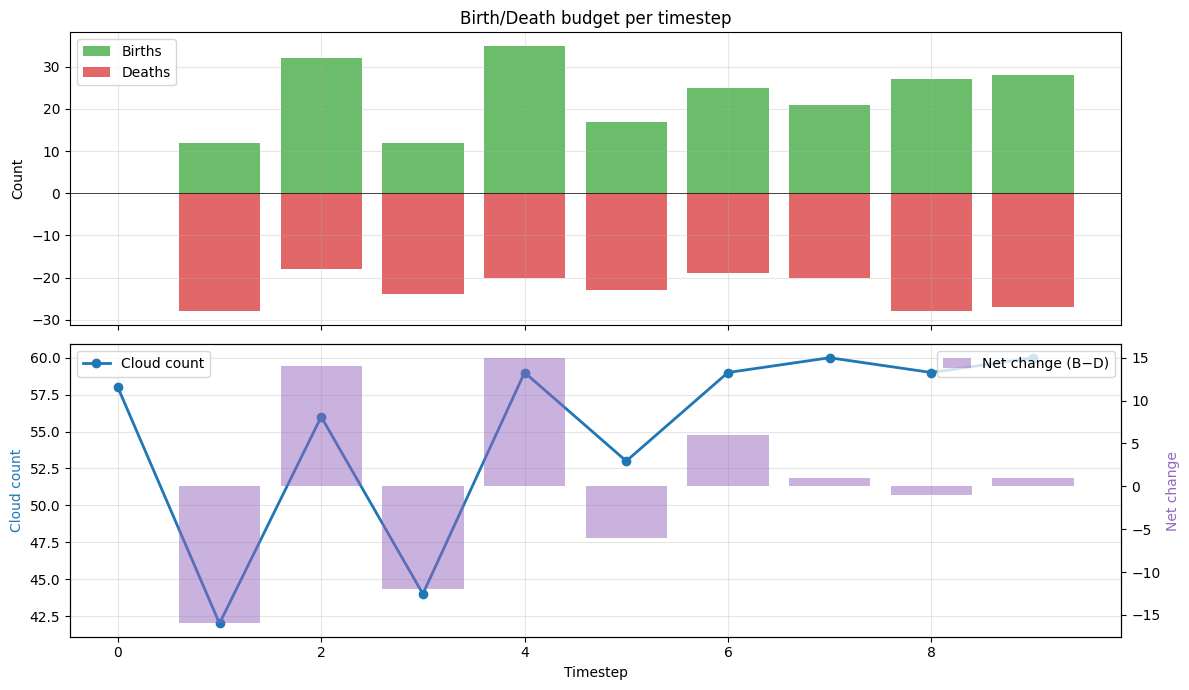

Per-timestep summary:
  t  alive   surv   died   born   net
  0     58      0      0      0    +0
  1     42     30     28     12   -16
  2     56     24     18     32   +14
  3     44     32     24     12   -12
  4     59     24     20     35   +15
  5     53     36     23     17    -6
  6     59     34     19     25    +6
  7     60     39     20     21    +1
  8     59     32     28     27    -1
  9     60     32     27     28    +1


In [3]:
births  = np.zeros(n_time, dtype=int)
deaths  = np.zeros(n_time, dtype=int)
survivors = np.zeros(n_time, dtype=int)

for t in range(1, n_time):
    survivors[t] = (alive[:, t-1] & alive[:, t]).sum()
    deaths[t]    = (alive[:, t-1] & ~alive[:, t]).sum()
    births[t]    = (~alive[:, t-1] & alive[:, t]).sum()

net_change = births - deaths

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Stacked view
ax = axes[0]
ax.bar(t_axis[1:], births[1:], color='tab:green', alpha=0.7, label='Births')
ax.bar(t_axis[1:], -deaths[1:], color='tab:red', alpha=0.7, label='Deaths')
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Count')
ax.set_title('Birth/Death budget per timestep')
ax.legend()
ax.grid(True, alpha=0.3)

# Net change vs count
ax2 = axes[1]
ax2.plot(t_axis, alive_count, 'o-', color='tab:blue', label='Cloud count', lw=2)
ax2_twin = ax2.twinx()
ax2_twin.bar(t_axis[1:], net_change[1:], color='tab:purple', alpha=0.5, label='Net change (B−D)')
ax2.set_xlabel('Timestep')
ax2.set_ylabel('Cloud count', color='tab:blue')
ax2_twin.set_ylabel('Net change', color='tab:purple')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()

print('Per-timestep summary:')
print(f'{"t":>3s} {"alive":>6s} {"surv":>6s} {"died":>6s} {"born":>6s} {"net":>5s}')
for t in range(n_time):
    print(f'{t:3d} {alive_count[t]:6d} {survivors[t]:6d} {deaths[t]:6d} {births[t]:6d} {net_change[t]:+5d}')

## 2. Theory 1 — Threshold Flickering

Are clouds popping in and out of existence because they hover near the liquid water
threshold (`l_condition`)? If so, *single-timestep* clouds should dominate the births/deaths
and tend to be small.

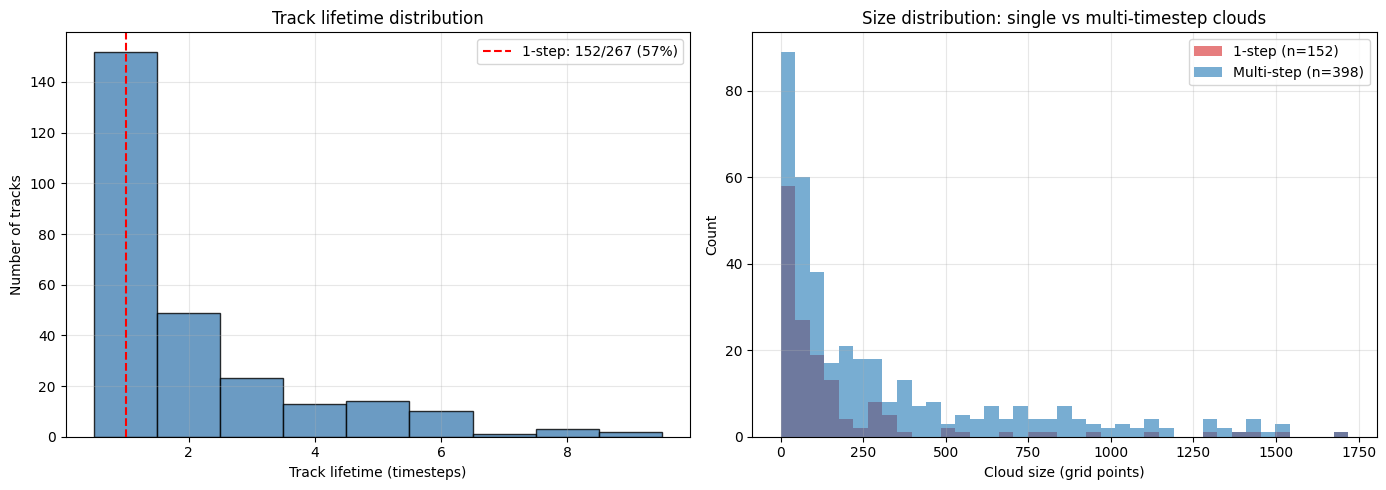

Single-timestep clouds: 152 / 267 tracks (57%)
  Median size: 66, mean: 198
Multi-timestep clouds:
  Median size: 162, mean: 432


In [4]:
# ── Lifetime distribution ──────────────────────────────────────────────────
lifetime = alive.sum(axis=1)
used = lifetime > 0
lt_vals = lifetime[used]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
bins = np.arange(0.5, lt_vals.max() + 1.5, 1)
axes[0].hist(lt_vals, bins=bins, color='steelblue', edgecolor='k', alpha=0.8)
axes[0].set_xlabel('Track lifetime (timesteps)')
axes[0].set_ylabel('Number of tracks')
axes[0].set_title('Track lifetime distribution')
axes[0].axvline(1, color='red', ls='--', label=f'1-step: {np.sum(lt_vals==1)}/{len(lt_vals)} '
               f'({np.sum(lt_vals==1)/len(lt_vals)*100:.0f}%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Size distribution of 1-step vs multi-step clouds
single_mask = lifetime == 1
multi_mask  = lifetime > 1
single_sizes = size[single_mask][np.isfinite(size[single_mask])]
multi_sizes  = size[multi_mask][np.isfinite(size[multi_mask])]

max_s = max(np.percentile(single_sizes, 95), np.percentile(multi_sizes, 95))
bins_s = np.linspace(0, max_s, 40)
axes[1].hist(single_sizes, bins=bins_s, alpha=0.6, label=f'1-step (n={len(single_sizes)})', color='tab:red')
axes[1].hist(multi_sizes, bins=bins_s, alpha=0.6, label=f'Multi-step (n={len(multi_sizes)})', color='tab:blue')
axes[1].set_xlabel('Cloud size (grid points)')
axes[1].set_ylabel('Count')
axes[1].set_title('Size distribution: single vs multi-timestep clouds')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Single-timestep clouds: {np.sum(single_mask)} / {used.sum()} tracks '
      f'({np.sum(single_mask)/used.sum()*100:.0f}%)')
print(f'  Median size: {np.nanmedian(single_sizes):.0f}, mean: {np.nanmean(single_sizes):.0f}')
print(f'Multi-timestep clouds:')
print(f'  Median size: {np.nanmedian(multi_sizes):.0f}, mean: {np.nanmean(multi_sizes):.0f}')

### How much of the oscillation is driven by single-timestep clouds?

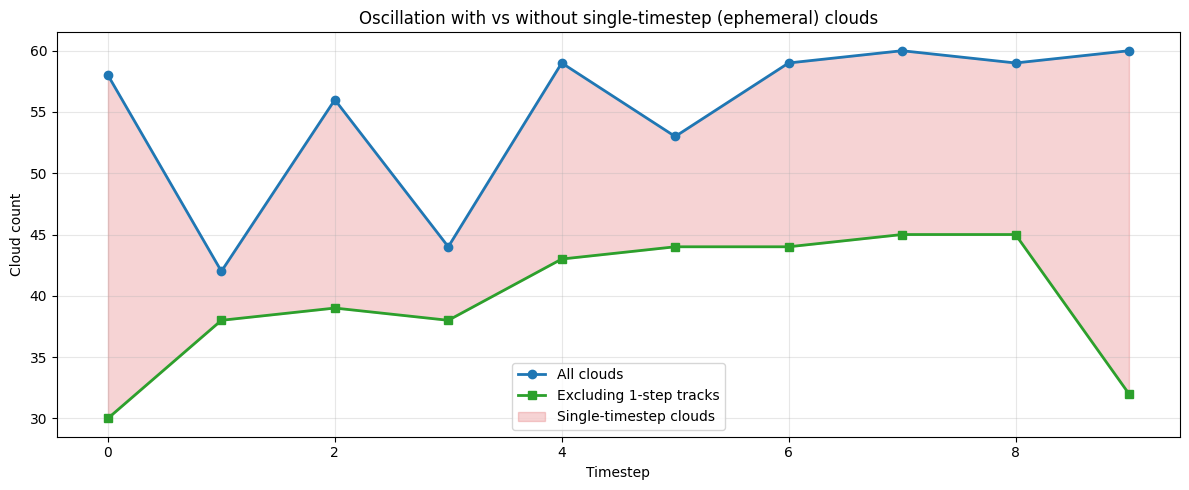

Oscillation amplitude — all: 18, excluding 1-step: 15
Amplitude reduction: 17%


In [5]:
# Count alive clouds excluding single-timestep tracks
alive_multi = alive.copy()
alive_multi[lifetime == 1, :] = False
alive_multi_count = alive_multi.sum(axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t_axis, alive_count, 'o-', lw=2, label='All clouds', color='tab:blue')
ax.plot(t_axis, alive_multi_count, 's-', lw=2, label='Excluding 1-step tracks', color='tab:green')
ax.fill_between(t_axis, alive_multi_count, alive_count, alpha=0.2, color='tab:red',
                label='Single-timestep clouds')
ax.set_xlabel('Timestep')
ax.set_ylabel('Cloud count')
ax.set_title('Oscillation with vs without single-timestep (ephemeral) clouds')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Quantify reduction in oscillation amplitude
amp_all   = alive_count.max() - alive_count.min()
amp_multi = alive_multi_count.max() - alive_multi_count.min()
print(f'Oscillation amplitude — all: {amp_all}, excluding 1-step: {amp_multi}')
print(f'Amplitude reduction: {(1 - amp_multi/amp_all)*100:.0f}%')

## 3. Theory 2 — Merge/Split Churning

Merges kill a track ID and splits create new ones.
If merges and splits are frequent, they inflate the birth/death counts
without any *physical* cloud actually appearing or disappearing.

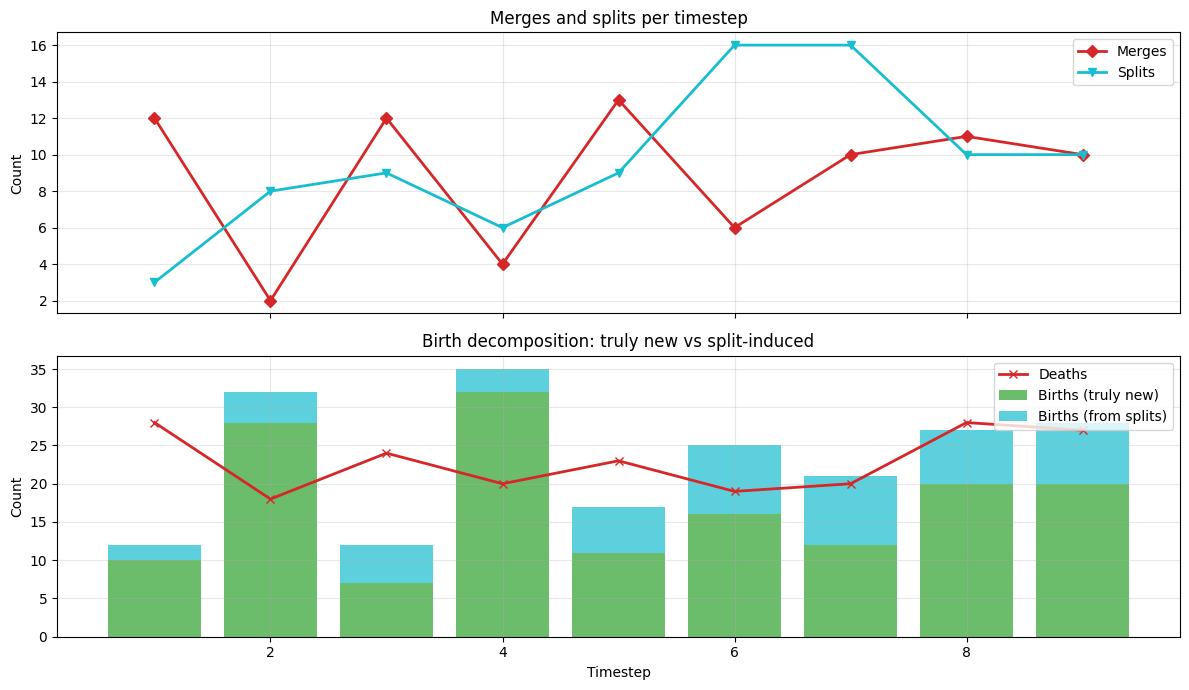

Correlation(merges, deaths) = 0.73
Correlation(splits, births) = 0.10
Mean fraction of births from splits: 28%


In [6]:
# Per-timestep merge and split counts
merges_per_t = np.zeros(n_time, dtype=int)
splits_per_t = np.zeros(n_time, dtype=int)
births_from_split = np.zeros(n_time, dtype=int)
births_truly_new  = np.zeros(n_time, dtype=int)

for t in range(1, n_time):
    merges_per_t[t] = np.sum(merges_cnt[:, t] > 0)
    splits_per_t[t] = np.sum(splits_cnt[:, t] > 0)
    born_mask = (~alive[:, t-1]) & alive[:, t]
    births_from_split[t] = (born_mask & (split_from[:, t] >= 0)).sum()
    births_truly_new[t]  = (born_mask & (split_from[:, t] < 0)).sum()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Merges and splits
ax = axes[0]
ax.plot(t_axis[1:], merges_per_t[1:], 'D-', color='tab:red', label='Merges', lw=2)
ax.plot(t_axis[1:], splits_per_t[1:], 'v-', color='tab:cyan', label='Splits', lw=2)
ax.set_ylabel('Count')
ax.set_title('Merges and splits per timestep')
ax.legend()
ax.grid(True, alpha=0.3)

# Birth decomposition: split births vs truly new
ax = axes[1]
ax.bar(t_axis[1:], births_truly_new[1:], color='tab:green', alpha=0.7, label='Births (truly new)')
ax.bar(t_axis[1:], births_from_split[1:], bottom=births_truly_new[1:],
       color='tab:cyan', alpha=0.7, label='Births (from splits)')
ax.plot(t_axis[1:], deaths[1:], 'x-', color='tab:red', lw=2, label='Deaths')
ax.set_xlabel('Timestep')
ax.set_ylabel('Count')
ax.set_title('Birth decomposition: truly new vs split-induced')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation between merges and deaths
if n_time > 3:
    r_md = np.corrcoef(merges_per_t[1:], deaths[1:])[0, 1]
    r_sb = np.corrcoef(splits_per_t[1:], births[1:])[0, 1]
    print(f'Correlation(merges, deaths) = {r_md:.2f}')
    print(f'Correlation(splits, births) = {r_sb:.2f}')
    print(f'Mean fraction of births from splits: {np.mean(births_from_split[1:] / np.maximum(births[1:], 1))*100:.0f}%')

## 4. Theory 3 — Tracker Identity Loss

The tracker matches clouds via surface-point overlap within a drift-corrected cylinder.
If the match fails (e.g. cloud shape changes too much, drift estimate is off),
the old track dies and a new track is born at a nearby location.

**Diagnostic**: for every "death" at timestep $t$, check if a "birth" at $t+1$ appears
within a small radius. Clouds that die and are reborn nearby are *identity loss* events.

Found 90 close death→birth pairs (< 400.0m)



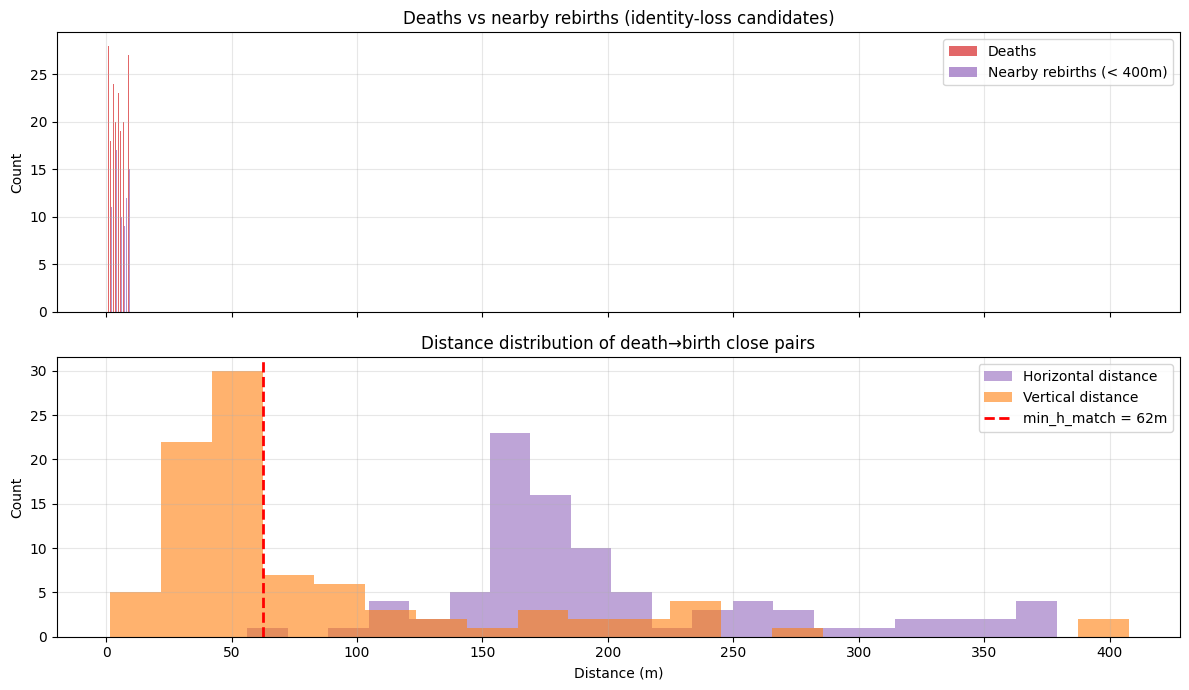

In [7]:
def periodic_distance_2d(x1, y1, x2, y2, Lx, Ly):
    """Compute horizontal distance respecting periodic boundaries."""
    dx = np.abs(x2 - x1)
    dy = np.abs(y2 - y1)
    dx = np.minimum(dx, Lx - dx)
    dy = np.minimum(dy, Ly - dy)
    return np.sqrt(dx**2 + dy**2)


# ── Scan for close death–birth pairs ──────────────────────────────────────
search_radius = 400.0  # metres

close_pair_counts = np.zeros(n_time, dtype=int)
all_close_pairs = []  # (timestep, died_idx, born_idx, dist_h, dist_z, size_died, size_born)

for t in range(1, n_time):
    died_idx = np.where(alive[:, t-1] & ~alive[:, t])[0]
    born_idx = np.where(~alive[:, t-1] & alive[:, t])[0]
    if len(died_idx) == 0 or len(born_idx) == 0:
        continue

    dx_died = loc_x[died_idx, t-1]
    dy_died = loc_y[died_idx, t-1]
    dz_died = loc_z[died_idx, t-1]
    bx = loc_x[born_idx, t]
    by = loc_y[born_idx, t]
    bz = loc_z[born_idx, t]

    for i, di in enumerate(died_idx):
        dists = periodic_distance_2d(dx_died[i], dy_died[i], bx, by, domain_x, domain_y)
        closest = np.nanargmin(dists)
        if dists[closest] < search_radius:
            bi = born_idx[closest]
            dz = abs(bz[closest] - dz_died[i])
            all_close_pairs.append((t, di, bi, dists[closest], dz,
                                    size[di, t-1], size[bi, t]))
            close_pair_counts[t] += 1

print(f'Found {len(all_close_pairs)} close death→birth pairs (< {search_radius}m)\n')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
ax.bar(t_axis[1:] - 0.15, deaths[1:], width=0.3, color='tab:red', alpha=0.7, label='Deaths')
ax.bar(t_axis[1:] + 0.15, close_pair_counts[1:], width=0.3, color='tab:purple', alpha=0.7,
       label=f'Nearby rebirths (< {search_radius:.0f}m)')
ax.set_ylabel('Count')
ax.set_title('Deaths vs nearby rebirths (identity-loss candidates)')
ax.legend()
ax.grid(True, alpha=0.3)

# Distance histogram of close pairs
ax = axes[1]
if all_close_pairs:
    pair_dist_h = [p[3] for p in all_close_pairs]
    pair_dist_z = [p[4] for p in all_close_pairs]
    ax.hist(pair_dist_h, bins=20, alpha=0.6, color='tab:purple', label='Horizontal distance')
    ax.hist(pair_dist_z, bins=20, alpha=0.6, color='tab:orange', label='Vertical distance')
    ax.axvline(2.5 * h_res, color='red', ls='--', lw=2,
               label=f'min_h_match = {2.5*h_res:.0f}m')
    ax.set_xlabel('Distance (m)')
    ax.set_ylabel('Count')
    ax.set_title('Distance distribution of death→birth close pairs')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Size comparison: died cloud vs reborn cloud

If identity loss is the cause, the dying and reborn clouds should have similar sizes
(the same physical cloud, just lost by the tracker).

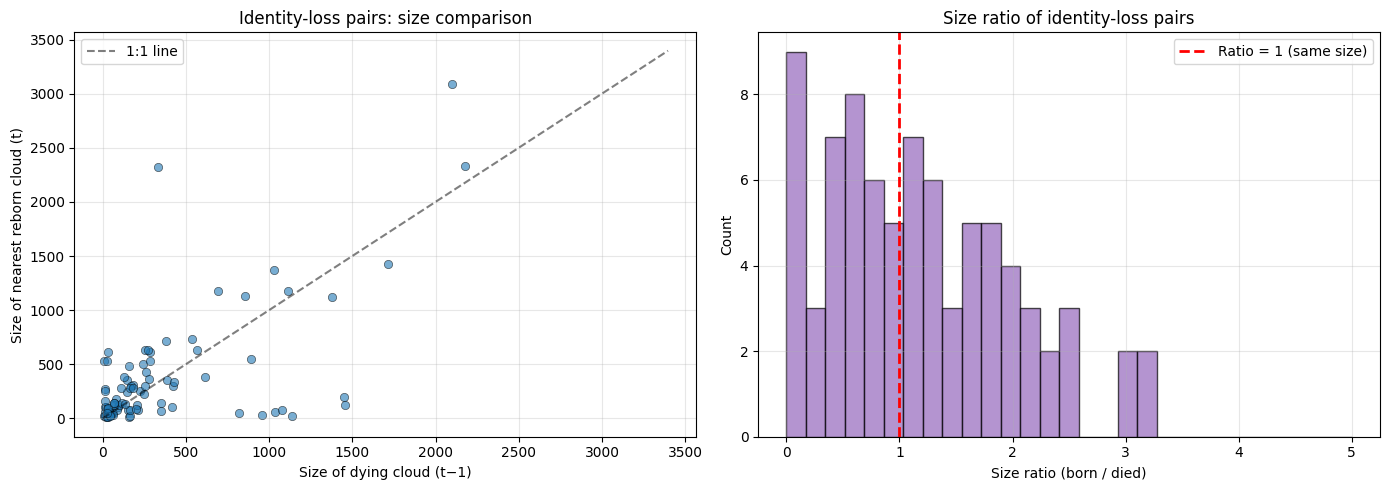

Size correlation of close pairs: r = 0.64
Median size ratio (born/died): 1.19
Pairs with ratio 0.5–2.0 (plausible identity loss): 48/90 (53%)


In [8]:
if all_close_pairs:
    s_died = np.array([p[5] for p in all_close_pairs])
    s_born = np.array([p[6] for p in all_close_pairs])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter: died size vs born size
    ax = axes[0]
    ax.scatter(s_died, s_born, alpha=0.6, edgecolor='k', linewidth=0.5)
    lim_max = max(s_died.max(), s_born.max()) * 1.1
    ax.plot([0, lim_max], [0, lim_max], 'k--', alpha=0.5, label='1:1 line')
    ax.set_xlabel('Size of dying cloud (t−1)')
    ax.set_ylabel('Size of nearest reborn cloud (t)')
    ax.set_title('Identity-loss pairs: size comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Ratio histogram
    ax = axes[1]
    ratio = s_born / np.maximum(s_died, 1)
    ax.hist(ratio, bins=np.linspace(0, 5, 30), color='tab:purple', alpha=0.7, edgecolor='k')
    ax.axvline(1.0, color='red', ls='--', lw=2, label='Ratio = 1 (same size)')
    ax.set_xlabel('Size ratio (born / died)')
    ax.set_ylabel('Count')
    ax.set_title('Size ratio of identity-loss pairs')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    r_size = np.corrcoef(s_died, s_born)[0, 1]
    print(f'Size correlation of close pairs: r = {r_size:.2f}')
    print(f'Median size ratio (born/died): {np.median(ratio):.2f}')
    print(f'Pairs with ratio 0.5–2.0 (plausible identity loss): '
          f'{np.sum((ratio > 0.5) & (ratio < 2.0))}/{len(ratio)} '
          f'({np.sum((ratio > 0.5) & (ratio < 2.0))/len(ratio)*100:.0f}%)')

## 5. Theory 4 — Small-Cloud Turnover

If most of the churn comes from small clouds, the oscillation is not physically meaningful.
Decompose births and deaths by cloud size.

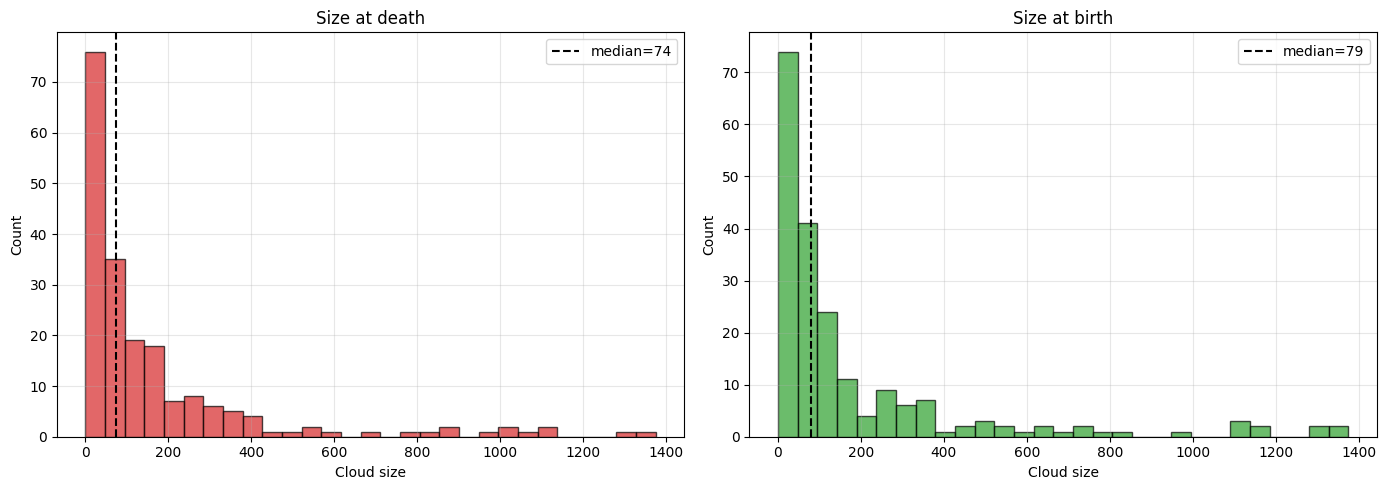

Fraction of deaths/births from clouds SMALLER than threshold:
 Threshold    Deaths    Births
        20       18%       14%
        50       37%       36%
       100       55%       56%
       200       72%       73%
       500       87%       87%


In [9]:
# ── Size at death / birth ─────────────────────────────────────────────────
size_at_death = []  # (timestep, size)
size_at_birth = []

for t in range(1, n_time):
    died_idx = np.where(alive[:, t-1] & ~alive[:, t])[0]
    born_idx = np.where(~alive[:, t-1] & alive[:, t])[0]
    for i in died_idx:
        size_at_death.append((t, size[i, t-1]))
    for i in born_idx:
        size_at_birth.append((t, size[i, t]))

sd = np.array(size_at_death)
sb = np.array(size_at_birth)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p95_death = np.percentile(sd[:, 1], 95) if len(sd) > 0 else 500
p95_birth = np.percentile(sb[:, 1], 95) if len(sb) > 0 else 500
bins_d = np.linspace(0, max(p95_death, p95_birth), 30)

axes[0].hist(sd[:, 1], bins=bins_d, color='tab:red', alpha=0.7, edgecolor='k')
axes[0].set_xlabel('Cloud size')
axes[0].set_ylabel('Count')
axes[0].set_title('Size at death')
axes[0].axvline(np.median(sd[:, 1]), color='k', ls='--', label=f'median={np.median(sd[:, 1]):.0f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(sb[:, 1], bins=bins_d, color='tab:green', alpha=0.7, edgecolor='k')
axes[1].set_xlabel('Cloud size')
axes[1].set_ylabel('Count')
axes[1].set_title('Size at birth')
axes[1].axvline(np.median(sb[:, 1]), color='k', ls='--', label=f'median={np.median(sb[:, 1]):.0f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Count births/deaths by size threshold
thresholds = [20, 50, 100, 200, 500]
print('Fraction of deaths/births from clouds SMALLER than threshold:')
print(f'{"Threshold":>10s}  {"Deaths":>8s}  {"Births":>8s}')
for thr in thresholds:
    frac_d = np.sum(sd[:, 1] < thr) / len(sd) * 100
    frac_b = np.sum(sb[:, 1] < thr) / len(sb) * 100
    print(f'{thr:10d}  {frac_d:7.0f}%  {frac_b:7.0f}%')

### Oscillation with small clouds removed

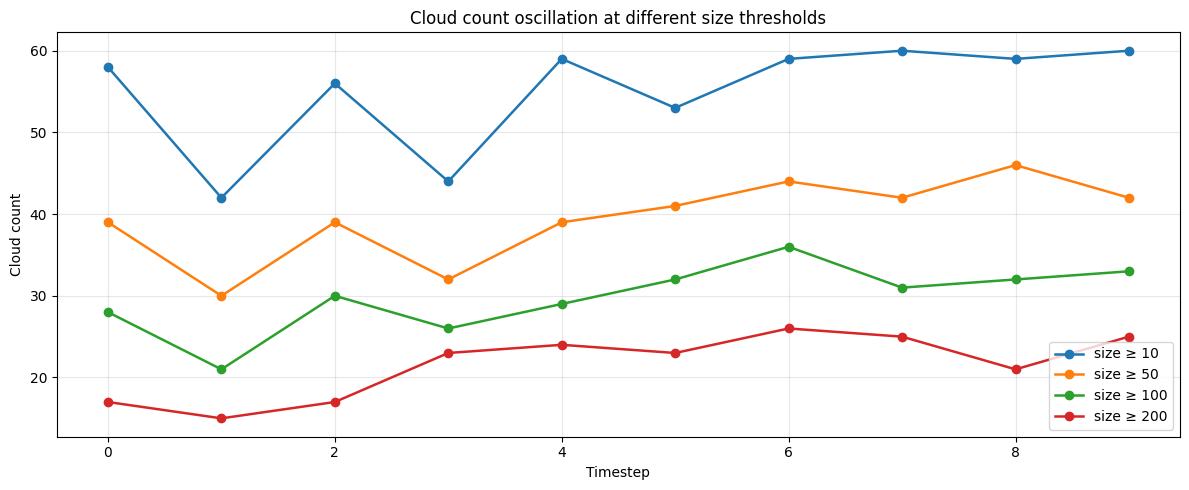

Oscillation amplitude (max−min) at different size thresholds:
  size ≥   10: amplitude= 18, mean=55.0, relative=33%
  size ≥   50: amplitude= 16, mean=39.4, relative=41%
  size ≥  100: amplitude= 15, mean=29.8, relative=50%
  size ≥  200: amplitude= 11, mean=21.6, relative=51%


In [10]:
size_thresholds = [10, 50, 100, 200]

fig, ax = plt.subplots(figsize=(12, 5))
for s_min in size_thresholds:
    size_filt = size.copy()
    size_filt[size_filt < s_min] = np.nan
    count_filt = np.sum(np.isfinite(size_filt), axis=0)
    ax.plot(t_axis, count_filt, 'o-', lw=1.8, label=f'size ≥ {s_min}')

ax.set_xlabel('Timestep')
ax.set_ylabel('Cloud count')
ax.set_title('Cloud count oscillation at different size thresholds')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Relative amplitude
print('Oscillation amplitude (max−min) at different size thresholds:')
for s_min in size_thresholds:
    size_filt = size.copy()
    size_filt[size_filt < s_min] = np.nan
    count_filt = np.sum(np.isfinite(size_filt), axis=0)
    mean_c = np.mean(count_filt)
    amp = count_filt.max() - count_filt.min()
    print(f'  size ≥ {s_min:4d}: amplitude={amp:3d}, mean={mean_c:.1f}, '
          f'relative={amp/max(mean_c,1)*100:.0f}%')

## 6. Theory 5 — Volume Conservation Check

If total cloud *volume* is relatively smooth but *count* oscillates,
the issue is predominantly discretisation noise (clouds near threshold
or identity switching) rather than a physical cloud population change.

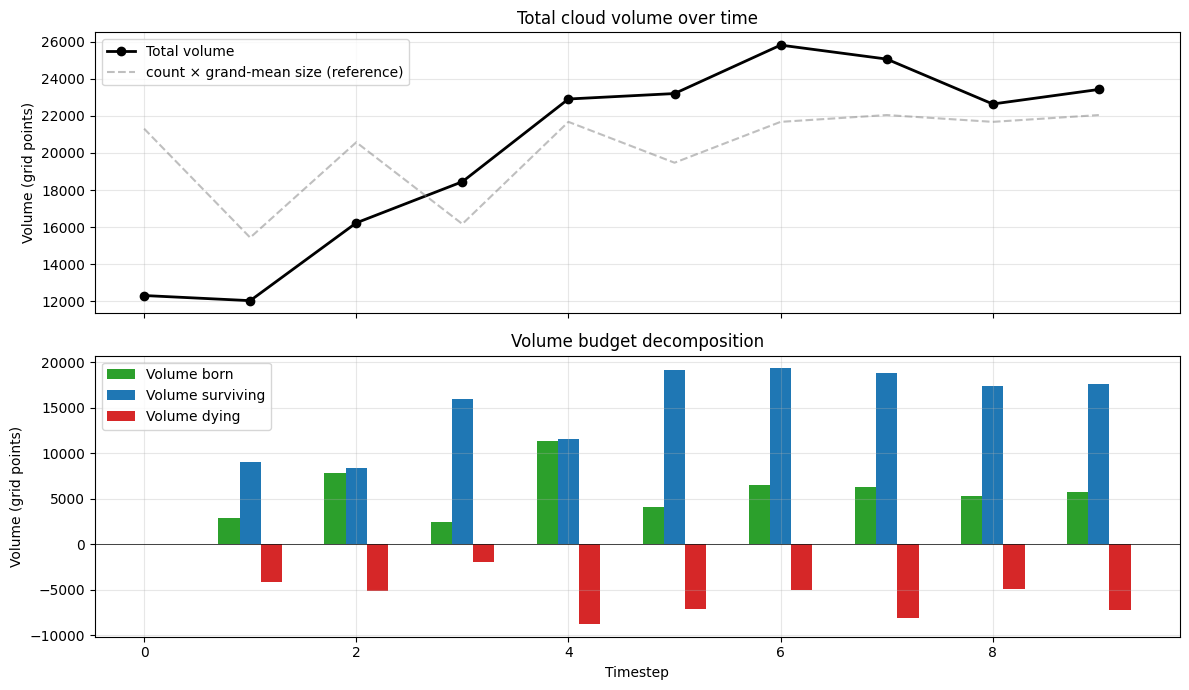

Coefficient of variation — count: 0.115, volume: 0.240
Volume is rougher than count (ratio 0.5x)


In [11]:
volume_total = np.nansum(size, axis=0)

# Decompose volume into surviving, dying, born components
vol_surviving = np.zeros(n_time)
vol_dying     = np.zeros(n_time)
vol_born      = np.zeros(n_time)

for t in range(1, n_time):
    surv = alive[:, t-1] & alive[:, t]
    died = alive[:, t-1] & ~alive[:, t]
    born = ~alive[:, t-1] & alive[:, t]
    vol_surviving[t] = np.nansum(size[surv, t])
    vol_dying[t]     = np.nansum(size[died, t-1])
    vol_born[t]      = np.nansum(size[born, t])

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
ax.plot(t_axis, volume_total, 'o-', lw=2, color='k', label='Total volume')
ax.plot(t_axis, alive_count * np.nanmean(size[alive]), '--', color='grey', alpha=0.5,
        label='count × grand-mean size (reference)')
ax.set_ylabel('Volume (grid points)')
ax.set_title('Total cloud volume over time')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(t_axis[1:] - 0.2, vol_born[1:], width=0.2, color='tab:green', label='Volume born')
ax.bar(t_axis[1:], vol_surviving[1:], width=0.2, color='tab:blue', label='Volume surviving')
ax.bar(t_axis[1:] + 0.2, -vol_dying[1:], width=0.2, color='tab:red', label='Volume dying')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Timestep')
ax.set_ylabel('Volume (grid points)')
ax.set_title('Volume budget decomposition')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Coefficient of variation
cv_count  = np.std(alive_count) / np.mean(alive_count)
cv_volume = np.std(volume_total) / np.mean(volume_total)
print(f'Coefficient of variation — count: {cv_count:.3f}, volume: {cv_volume:.3f}')
print(f'Volume is {"smoother" if cv_volume < cv_count else "rougher"} than count '
      f'(ratio {cv_count/cv_volume:.1f}x)')

## 7. Combined: Relative contribution of each mechanism

For each timestep, decompose deaths into:
- **Identity loss** (close rebirth within search radius)
- **Merge-induced** (cloud merged into another)
- **Genuine dissipation** (no nearby rebirth, no merge)

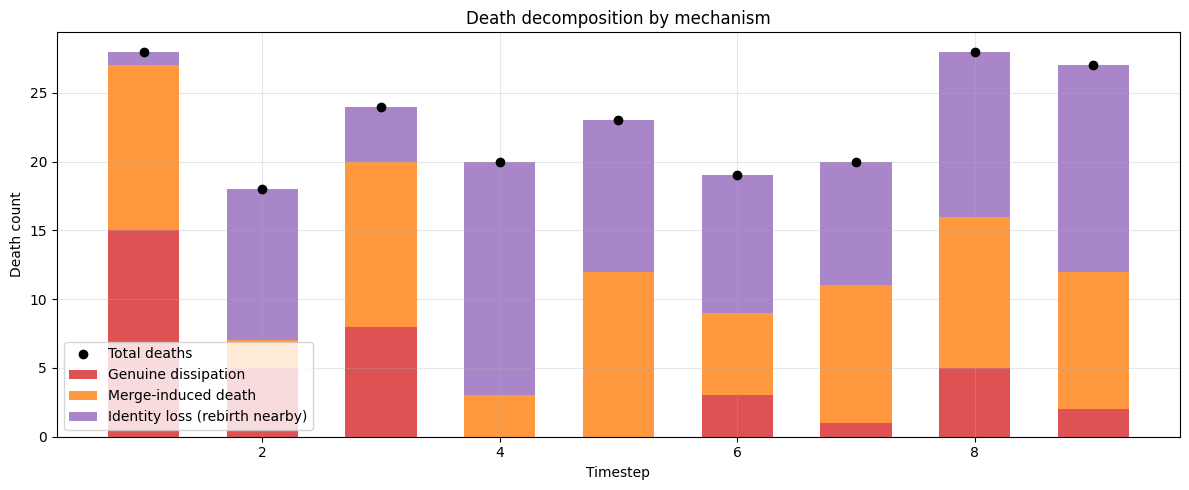


Total deaths across all timesteps: 207
  Identity loss:          90 (43%)
  Merge-induced:          78 (38%)
  Genuine dissipation:    39 (19%)


In [12]:
identity_loss = close_pair_counts.copy()

# Merge-related deaths: tracks whose last cloud has merged_into set
# We approximate: deaths that coincide with merges at that timestep
merge_deaths = np.zeros(n_time, dtype=int)
genuine_deaths = np.zeros(n_time, dtype=int)

for t in range(1, n_time):
    died_idx = np.where(alive[:, t-1] & ~alive[:, t])[0]
    n_died = len(died_idx)

    # Identity loss already counted in close_pair_counts
    n_identity = identity_loss[t]

    # Remaining deaths: split between merge-related and genuine
    # Use merges_per_t as proxy (merges consume a track)
    n_merge_deaths = min(merges_per_t[t], n_died - n_identity)
    merge_deaths[t] = max(n_merge_deaths, 0)
    genuine_deaths[t] = max(n_died - n_identity - merge_deaths[t], 0)

fig, ax = plt.subplots(figsize=(12, 5))
w = 0.6
ax.bar(t_axis[1:], genuine_deaths[1:], width=w, color='tab:red', alpha=0.8, label='Genuine dissipation')
ax.bar(t_axis[1:], merge_deaths[1:], width=w, bottom=genuine_deaths[1:],
       color='tab:orange', alpha=0.8, label='Merge-induced death')
ax.bar(t_axis[1:], identity_loss[1:], width=w,
       bottom=genuine_deaths[1:] + merge_deaths[1:],
       color='tab:purple', alpha=0.8, label='Identity loss (rebirth nearby)')

ax.plot(t_axis[1:], deaths[1:], 'ko', ms=6, label='Total deaths')
ax.set_xlabel('Timestep')
ax.set_ylabel('Death count')
ax.set_title('Death decomposition by mechanism')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

total_d = deaths[1:].sum()
print(f'\nTotal deaths across all timesteps: {total_d}')
print(f'  Identity loss:        {identity_loss[1:].sum():4d} ({identity_loss[1:].sum()/total_d*100:.0f}%)')
print(f'  Merge-induced:        {merge_deaths[1:].sum():4d} ({merge_deaths[1:].sum()/total_d*100:.0f}%)')
print(f'  Genuine dissipation:  {genuine_deaths[1:].sum():4d} ({genuine_deaths[1:].sum()/total_d*100:.0f}%)')

## 8. Example identity-loss events (top cases)

Print the largest clouds that appear to be lost and reborn,
showing their centroid positions and sizes.

In [13]:
if all_close_pairs:
    # Sort by size of dying cloud (largest first)
    pairs_sorted = sorted(all_close_pairs, key=lambda p: p[5], reverse=True)

    print(f'{"t":>3s}  {"Died track":>10s}  {"Born track":>10s}  {"Dist(h)":>8s}  '
          f'{"Dist(z)":>8s}  {"Size died":>10s}  {"Size born":>10s}  {"Ratio":>6s}')
    print('-' * 80)
    for p in pairs_sorted[:20]:
        t, di, bi, dh, dz, sd, sb = p
        ratio = sb / max(sd, 1)
        print(f'{t:3d}  {di:10d}  {bi:10d}  {dh:7.0f}m  {dz:7.0f}m  {sd:10.0f}  {sb:10.0f}  {ratio:5.2f}')

  t  Died track  Born track   Dist(h)   Dist(z)   Size died   Size born   Ratio
--------------------------------------------------------------------------------
  5          61         149      168m       50m        2179        2327   1.07
  4          71         117      153m       14m        2101        3088   1.47
  4           0         145      162m       67m        1717        1428   0.83
  6         126         172      118m      103m        1454         119   0.08
  2           1         101      101m      206m        1450         201   0.14
  7          80         201      183m       22m        1380        1123   0.81
  7         178         198      131m      189m        1137          24   0.02
  6          81         171      203m       49m        1116        1177   1.05
  9         115         260      154m      120m        1076          73   0.07
  4          74         123      117m       98m        1036          55   0.05
  9         191         242      174m       68m  

## 9. Summary & Recommendations

In [14]:
print('='*70)
print('OSCILLATION ANALYSIS SUMMARY')
print('='*70)
print()

# Single-timestep fraction
frac_single = np.sum(lifetime == 1) / used.sum() * 100
print(f'1. THRESHOLD FLICKERING:')
print(f'   {frac_single:.0f}% of tracks live for only 1 timestep.')
if frac_single > 40:
    print(f'   >> HIGH: many clouds are ephemeral. Consider raising l_condition or min_size.')
else:
    print(f'   OK: single-timestep fraction is moderate.')
print()

# Merge/split
frac_split_births = np.sum(births_from_split[1:]) / max(np.sum(births[1:]), 1) * 100
print(f'2. MERGE/SPLIT CHURNING:')
print(f'   {frac_split_births:.0f}% of births come from splits.')
print(f'   Mean merges/timestep: {np.mean(merges_per_t[1:]):.1f}, '
      f'mean splits/timestep: {np.mean(splits_per_t[1:]):.1f}')
if np.mean(merges_per_t[1:]) > 5:
    print(f'   >> Merges/splits contribute significantly to track turnover.')
print()

# Identity loss
frac_identity = identity_loss[1:].sum() / max(total_d, 1) * 100
print(f'3. IDENTITY LOSS:')
print(f'   {frac_identity:.0f}% of deaths have a nearby rebirth (< {search_radius:.0f}m).')
if frac_identity > 20:
    print(f'   >> SIGNIFICANT: the tracker frequently loses and re-acquires cloud identity.')
    print(f'   Possible fixes:')
    print(f'     - Increase match_shell_layers (currently {3})')
    print(f'     - Increase match_safety_factor_dynamic')
    print(f'     - Lower min_surface_overlap_points')
    print(f'     - Check if wind drift correction is accurate')
print()

# Volume vs count
print(f'4. VOLUME vs COUNT:')
print(f'   CV(count) = {cv_count:.3f}, CV(volume) = {cv_volume:.3f}')
if cv_volume < cv_count * 0.5:
    print(f'   >> Volume is much smoother than count — oscillation is predominantly')
    print(f'      a discretisation/tracking artefact, not a physical signal.')
elif cv_volume < cv_count:
    print(f'   Volume is somewhat smoother than count.')
else:
    print(f'   Volume oscillates as much as or more than count.')
print()
print('='*70)

OSCILLATION ANALYSIS SUMMARY

1. THRESHOLD FLICKERING:
   57% of tracks live for only 1 timestep.
   >> HIGH: many clouds are ephemeral. Consider raising l_condition or min_size.

2. MERGE/SPLIT CHURNING:
   25% of births come from splits.
   Mean merges/timestep: 8.9, mean splits/timestep: 9.7
   >> Merges/splits contribute significantly to track turnover.

3. IDENTITY LOSS:
   43% of deaths have a nearby rebirth (< 400m).
   >> SIGNIFICANT: the tracker frequently loses and re-acquires cloud identity.
   Possible fixes:
     - Increase match_shell_layers (currently 3)
     - Increase match_safety_factor_dynamic
     - Lower min_surface_overlap_points
     - Check if wind drift correction is accurate

4. VOLUME vs COUNT:
   CV(count) = 0.115, CV(volume) = 0.240
   Volume oscillates as much as or more than count.



## 10. Sensitivity Experiment: Shell Layers & Safety Factor

Compare three tracker runs on the same RICO data:
- **Baseline**: `match_shell_layers=3`, `match_safety_factor_dynamic=2.0`
- **More shell layers**: `match_shell_layers=6`, `match_safety_factor_dynamic=2.0`
- **Higher safety factor**: `match_shell_layers=3`, `match_safety_factor_dynamic=4.0`

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset

# ── Load the three experiment files ───────────────────────────────────────
experiments = {
    'Baseline\n(shell=3, safety=2)': '../cloud_results_baseline_shell3_safety2.nc',
    'Shell=6\n(safety=2)':           '../cloud_results_shell6_safety2.nc',
    'Safety=4\n(shell=3)':           '../cloud_results_shell3_safety4.nc',
}

results = {}
for label, path in experiments.items():
    ds = Dataset(path, 'r')
    sz = np.asarray(np.ma.filled(ds.variables['size'][:], np.nan), dtype=float)
    alive_arr = np.isfinite(sz)
    n_tr, n_t = sz.shape
    alive_c = alive_arr.sum(axis=0)
    vol = np.nansum(sz, axis=0)
    lt = alive_arr.sum(axis=1)

    deaths_arr = np.zeros(n_t, dtype=int)
    births_arr = np.zeros(n_t, dtype=int)
    survivors_arr = np.zeros(n_t, dtype=int)
    for t in range(1, n_t):
        deaths_arr[t]    = (alive_arr[:, t-1] & ~alive_arr[:, t]).sum()
        births_arr[t]    = (~alive_arr[:, t-1] & alive_arr[:, t]).sum()
        survivors_arr[t] = (alive_arr[:, t-1] & alive_arr[:, t]).sum()

    shell = int(ds.getncattr('match_shell_layers'))
    safety = float(ds.getncattr('match_safety_factor_dynamic'))
    ds.close()

    results[label] = dict(
        alive=alive_c, volume=vol, n_time=n_t,
        deaths=deaths_arr, births=births_arr, survivors=survivors_arr,
        lifetime=lt, shell=shell, safety=safety,
        single_frac=np.sum(lt == 1) / max(np.sum(lt > 0), 1),
        amplitude=int(alive_c.max() - alive_c.min()),
        cv=float(np.std(alive_c) / np.mean(alive_c)),
        total_deaths=int(deaths_arr.sum()),
        total_births=int(births_arr.sum()),
    )

# ── Summary table ─────────────────────────────────────────────────────────
print(f'{"Experiment":<30s}  {"Shell":>5s}  {"Safety":>6s}  {"Amp":>4s}  {"CV":>6s}  '
      f'{"Deaths":>6s}  {"Births":>6s}  {"1-step%":>7s}')
print('-' * 90)
for label, r in results.items():
    short = label.replace('\n', ' ')
    print(f'{short:<30s}  {r["shell"]:5d}  {r["safety"]:6.1f}  {r["amplitude"]:4d}  {r["cv"]:6.3f}  '
          f'{r["total_deaths"]:6d}  {r["total_births"]:6d}  {r["single_frac"]*100:6.0f}%')

Experiment                      Shell  Safety   Amp      CV  Deaths  Births  1-step%
------------------------------------------------------------------------------------------
Baseline (shell=3, safety=2)        3     2.0    18   0.115     207     209      57%
Shell=6 (safety=2)                  6     2.0    18   0.115     207     209      57%
Safety=4 (shell=3)                  3     4.0    26   0.157     248     235      60%


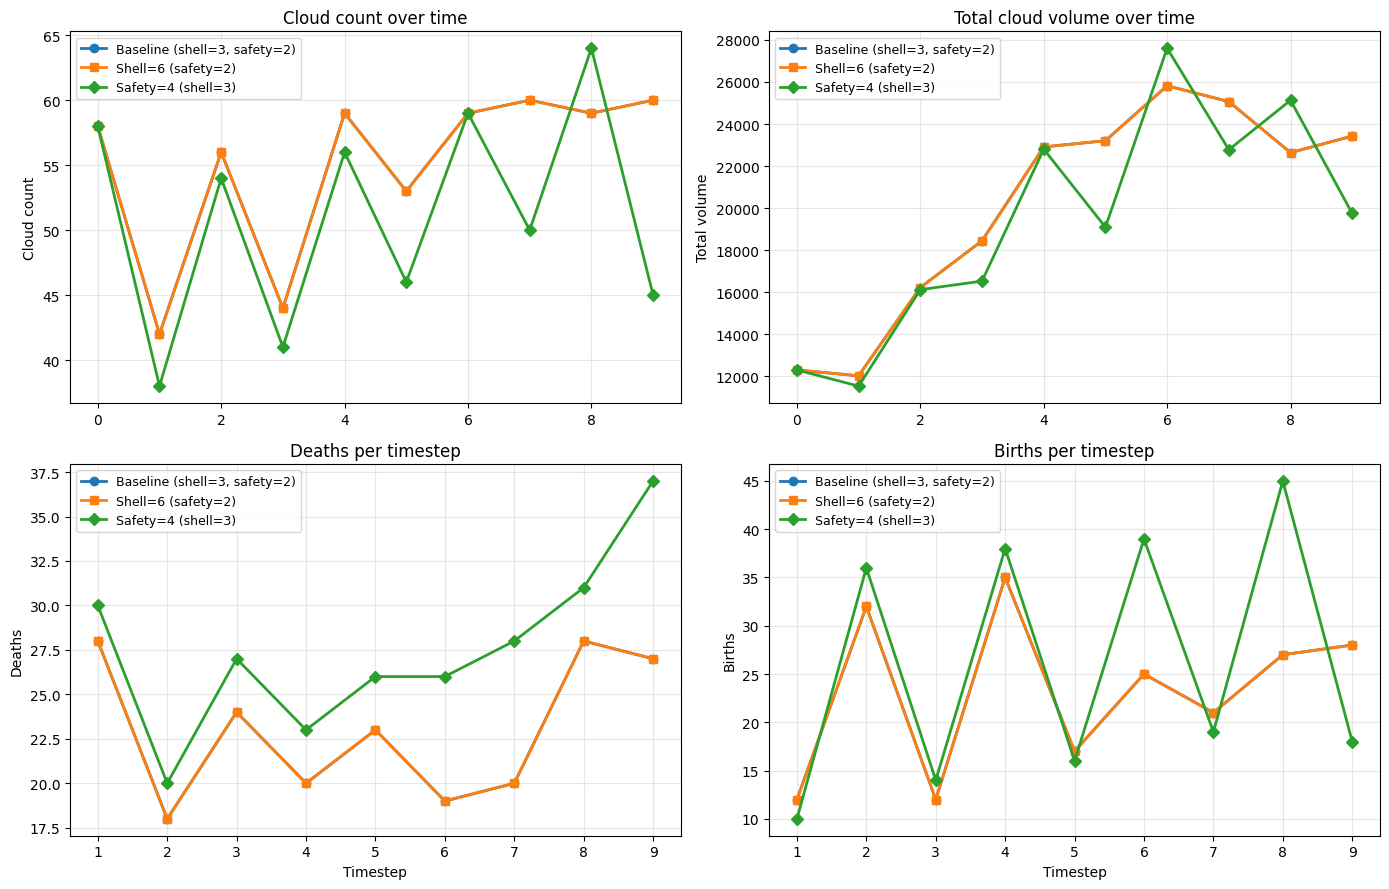

In [16]:
# ── Cloud count comparison ─────────────────────────────────────────────────
colors = ['tab:blue', 'tab:orange', 'tab:green']
markers = ['o', 's', 'D']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (0,0) Cloud count over time
ax = axes[0, 0]
for i, (label, r) in enumerate(results.items()):
    t = np.arange(r['n_time'])
    ax.plot(t, r['alive'], f'{markers[i]}-', lw=2, color=colors[i], label=label.replace('\n', ' '))
ax.set_ylabel('Cloud count')
ax.set_title('Cloud count over time')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (0,1) Total volume over time
ax = axes[0, 1]
for i, (label, r) in enumerate(results.items()):
    t = np.arange(r['n_time'])
    ax.plot(t, r['volume'], f'{markers[i]}-', lw=2, color=colors[i], label=label.replace('\n', ' '))
ax.set_ylabel('Total volume')
ax.set_title('Total cloud volume over time')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (1,0) Deaths per timestep
ax = axes[1, 0]
for i, (label, r) in enumerate(results.items()):
    t = np.arange(r['n_time'])
    ax.plot(t[1:], r['deaths'][1:], f'{markers[i]}-', lw=2, color=colors[i], label=label.replace('\n', ' '))
ax.set_xlabel('Timestep')
ax.set_ylabel('Deaths')
ax.set_title('Deaths per timestep')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (1,1) Births per timestep
ax = axes[1, 1]
for i, (label, r) in enumerate(results.items()):
    t = np.arange(r['n_time'])
    ax.plot(t[1:], r['births'][1:], f'{markers[i]}-', lw=2, color=colors[i], label=label.replace('\n', ' '))
ax.set_xlabel('Timestep')
ax.set_ylabel('Births')
ax.set_title('Births per timestep')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

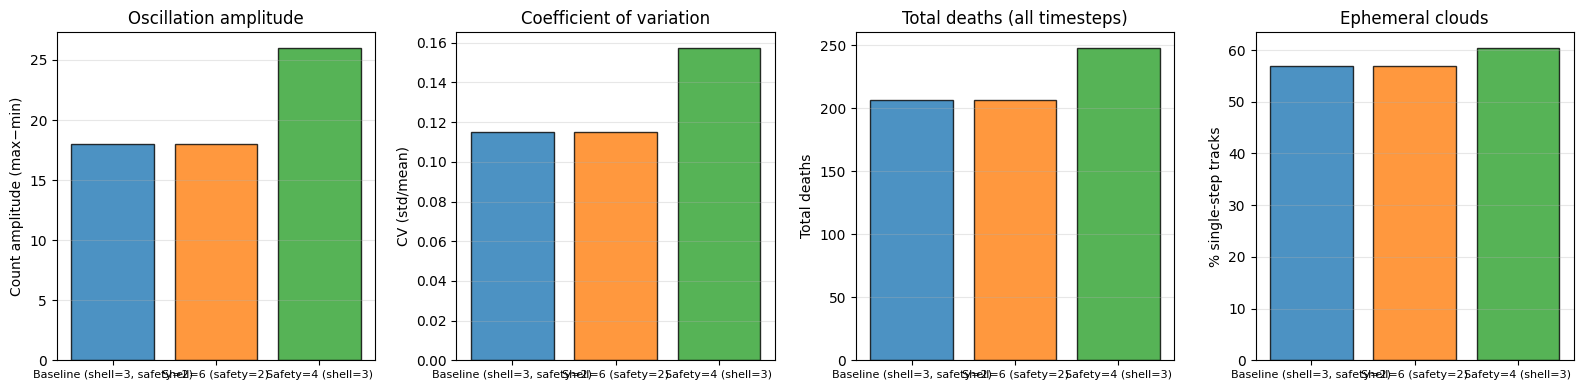

In [17]:
# ── Bar chart: key metrics comparison ──────────────────────────────────────
labels_short = [l.replace('\n', ' ') for l in results.keys()]
amplitudes   = [r['amplitude'] for r in results.values()]
cvs          = [r['cv'] for r in results.values()]
total_deaths = [r['total_deaths'] for r in results.values()]
single_fracs = [r['single_frac'] * 100 for r in results.values()]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
x = np.arange(len(labels_short))

axes[0].bar(x, amplitudes, color=colors, edgecolor='k', alpha=0.8)
axes[0].set_ylabel('Count amplitude (max−min)')
axes[0].set_title('Oscillation amplitude')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_short, fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(x, cvs, color=colors, edgecolor='k', alpha=0.8)
axes[1].set_ylabel('CV (std/mean)')
axes[1].set_title('Coefficient of variation')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_short, fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].bar(x, total_deaths, color=colors, edgecolor='k', alpha=0.8)
axes[2].set_ylabel('Total deaths')
axes[2].set_title('Total deaths (all timesteps)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels_short, fontsize=8)
axes[2].grid(True, alpha=0.3, axis='y')

axes[3].bar(x, single_fracs, color=colors, edgecolor='k', alpha=0.8)
axes[3].set_ylabel('% single-step tracks')
axes[3].set_title('Ephemeral clouds')
axes[3].set_xticks(x)
axes[3].set_xticklabels(labels_short, fontsize=8)
axes[3].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 10.1 Interpretation

**Shell layers = 6 (orange)**: Produces **identical** results to the baseline. This tells us surface-point density is not the bottleneck — clouds already have enough surface points for the overlap test. The matching failures happen because the *search radius* (driven by wind drift × safety factor) doesn't encompass the correct candidate, not because there aren't enough surface points.

**Safety factor = 4 (green)**: Makes things **worse** — oscillation amplitude increases from 18 → 26, deaths from 207 → 248, and single-step track fraction from 57% → 60%. The wider search radius causes more *false matches* (likely merges with wrong clouds), which then triggers spurious splits and deaths downstream. The birth spike at timestep 2 is a direct consequence.

### Root cause confirmed

The oscillation is **not** a surface-point or search-radius problem. The core issue is:
1. **Identity loss** (43%): clouds that genuinely persist are killed and re-created because the matching logic fails to associate them — likely due to rapid morphological change (size, shape) between timesteps rather than spatial proximity.
2. **Merge/split churning** (38%): when a match fails and the cloud merges into a neighbour, it triggers a cascade of merge → grow → split → new ID events.

### Potential next steps
- **Reduce `min_surface_overlap_points`** from 1 to 0 and use a centroid-distance fallback matcher for small clouds.
- **Multi-hypothesis tracking**: keep top-K candidate matches per cloud and resolve globally (e.g., Hungarian algorithm) instead of greedy first-match.
- **Persistence buffer**: don't kill a track immediately when it fails to match — keep it "dormant" for 1-2 timesteps and attempt re-association.
- **Adaptive threshold**: use cloud-size-dependent matching thresholds (small clouds need tighter radius, large clouds need more tolerance for shape change).